# 📊 Notebook 1 — Data Preparation
**Datathon VinTelligence 2026 | Revenue & COGS Forecasting**

Pipeline: `01_data_preparation` → `02_baseline_models` → `03_advanced_ensemble` → `04_breakthrough`

**Goal:** Load raw data, validate, clean, and engineer auxiliary static features (zero future leakage).

**Outputs saved to** `data/data_clean/`:
- `sales_clean.csv` — cleaned daily sales with full date index
- `aux_web_profile.csv` — web traffic medians by (month, DOW)
- `aux_orders_profile.csv` — order count medians by (month, DOW)
- `aux_returns_profile.csv` — return count by month
- `aux_promos_profile.csv` — promo count + avg discount by month
- `prophet_holidays.csv` — holiday DataFrame for Prophet (with windows)
- `calendar_features.csv` — Vietnamese calendar features for all dates 2012→2024-07-01

## 0. Environment Setup

In [43]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────
# Adjust DATA_DIR to your environment:
#   Local:  Path('g:/My Drive/Datathon_VinTelligence/data/datathon-2026-round-1')
#   Colab:  Path('/content/drive/My Drive/Datathon_VinTelligence/data/datathon-2026-round-1')

# ── Plot style ─────────────────────────────────────────────────────────────
# ── Auto-detect environment & set paths ─────────────────────────────────
import os, sys

def _detect_base_dir():
    """Auto-detect BASE_DIR: works on Colab, local Windows, and local Linux."""
    # 1. Google Colab
    if 'google.colab' in sys.modules or os.path.exists('/content/drive'):
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        return Path('/content/drive/My Drive/Datathon_VinTelligence')
    # 2. Local — find project root (the folder containing 'data/')
    try:
        nb_dir = Path(__file__).resolve().parent
    except NameError:
        nb_dir = Path().resolve()  # in .ipynb, cwd = notebook folder
    for candidate in [nb_dir, nb_dir.parent, nb_dir.parent.parent]:
        if (candidate / 'data').exists():
            return candidate
    return nb_dir.parent  # last-resort fallback

BASE_DIR  = _detect_base_dir()
DATA_DIR  = BASE_DIR / 'data' / 'datathon-2026-round-1'
CLEAN_DIR = BASE_DIR / 'data' / 'data_clean'
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print(f'ENV       : {"Colab" if os.path.exists("/content") else "Local"}')
print(f'BASE_DIR  : {BASE_DIR}')
print(f'DATA_DIR  : {DATA_DIR}')
print(f'CLEAN_DIR : {CLEAN_DIR}')

plt.rcParams.update({
    'figure.figsize': (16, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100,
})

print(f'CLEAN_DIR : {CLEAN_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ENV       : Colab
BASE_DIR  : /content/drive/My Drive/Datathon_VinTelligence
DATA_DIR  : /content/drive/My Drive/Datathon_VinTelligence/data/datathon-2026-round-1
CLEAN_DIR : /content/drive/My Drive/Datathon_VinTelligence/data/data_clean
CLEAN_DIR : /content/drive/My Drive/Datathon_VinTelligence/data/data_clean


## 1. Load Raw Data

In [44]:
df_sales   = pd.read_csv(DATA_DIR / 'sales.csv',       parse_dates=['Date'])
df_web     = pd.read_csv(DATA_DIR / 'web_traffic.csv', parse_dates=['date'])
df_orders  = pd.read_csv(DATA_DIR / 'orders.csv',      parse_dates=['order_date'])
df_returns = pd.read_csv(DATA_DIR / 'returns.csv',     parse_dates=['return_date'])
df_promos  = pd.read_csv(DATA_DIR / 'promotions.csv',  parse_dates=['start_date', 'end_date'])
df_sample  = pd.read_csv(DATA_DIR / 'sample_submission.csv', parse_dates=['Date'])

datasets = {
    'Sales':      df_sales,
    'Web Traffic':df_web,
    'Orders':     df_orders,
    'Returns':    df_returns,
    'Promotions': df_promos,
}

rows = []
for name, df in datasets.items():
    rows.append({
        'Dataset': name,
        'Rows': f'{len(df):,}',
        'Columns': df.shape[1],
        'Missing%': f"{df.isnull().mean().mean()*100:.2f}%",
        'Duplicates': df.duplicated().sum(),
    })
display(pd.DataFrame(rows).set_index('Dataset'))

,Rows,Columns,Missing%,Duplicates
Dataset,,,,
Sales,"3,833",3,0.00%,0
Web Traffic,"3,652",7,0.00%,0
Orders,"646,945",8,0.00%,0
Returns,"39,939",7,0.00%,0
Promotions,50,10,8.00%,0


## 2. Sales Data Validation & Cleaning

In [45]:
# Sort & set index
df_sales = df_sales.sort_values('Date').reset_index(drop=True)
print(f'Sales range: {df_sales.Date.min().date()} → {df_sales.Date.max().date()}')
print(f'Total rows : {len(df_sales):,}')

# Check for missing dates
full_range = pd.date_range(df_sales.Date.min(), df_sales.Date.max(), freq='D')
missing_dates = full_range.difference(df_sales.Date)
print(f'Missing dates: {len(missing_dates)}')
if len(missing_dates) > 0:
    print(missing_dates)

# Duplicate dates
dups = df_sales[df_sales.Date.duplicated(keep=False)]
print(f'Duplicate date rows: {len(dups)}')

# Negative values
print(f'Negative Revenue: {(df_sales.Revenue <= 0).sum()}')
print(f'Negative COGS   : {(df_sales.COGS <= 0).sum()}')

Sales range: 2012-07-04 → 2022-12-31
Total rows : 3,833
Missing dates: 0
Duplicate date rows: 0
Negative Revenue: 0
Negative COGS   : 0


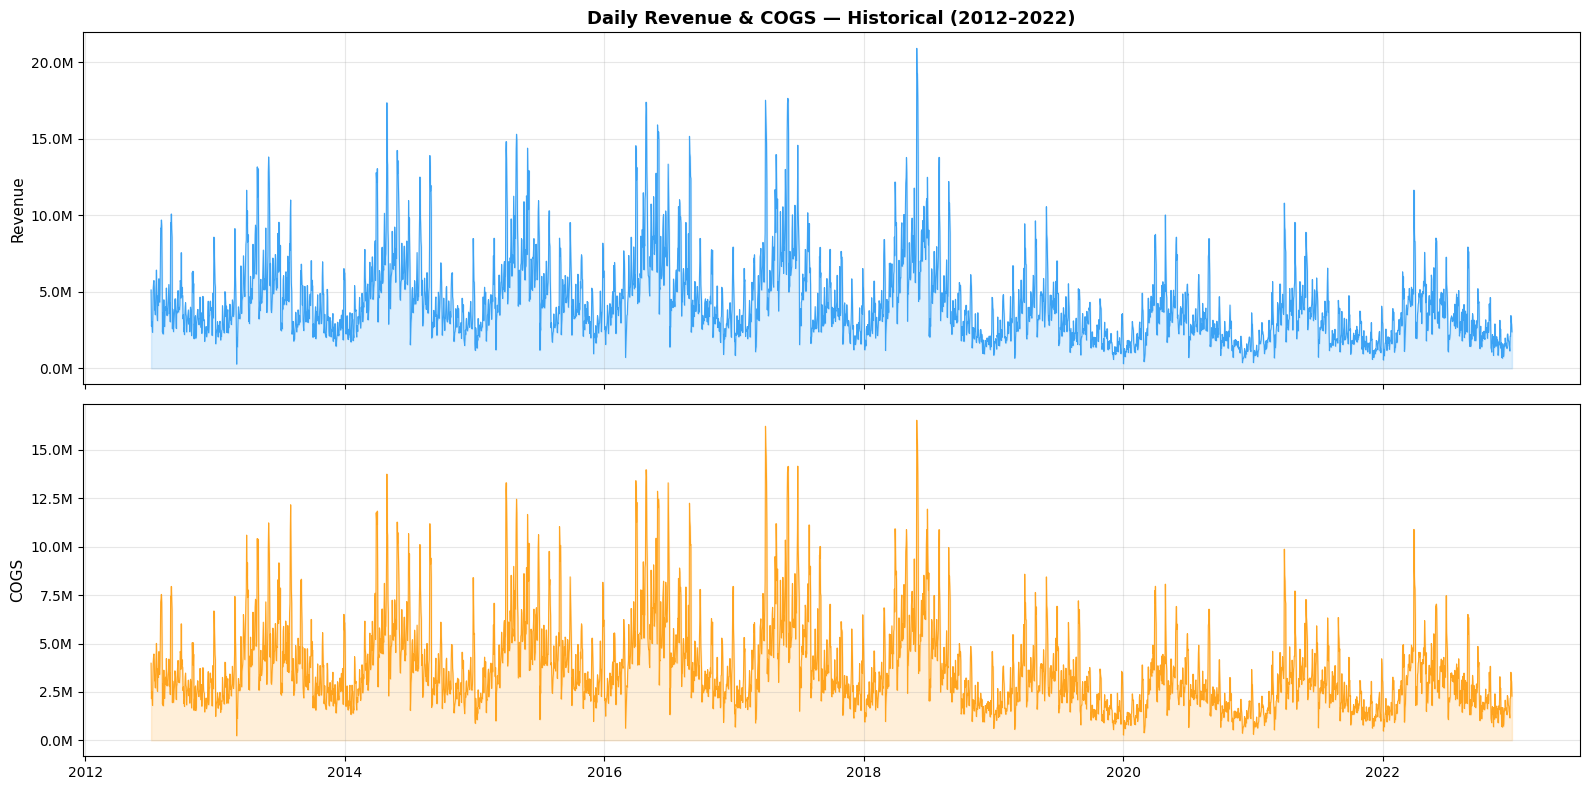

In [46]:
# Plot Revenue and COGS over time
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
for ax, col, color in zip(axes, ['Revenue', 'COGS'], ['#2196F3', '#FF9800']):
    ax.plot(df_sales.Date, df_sales[col], lw=0.8, color=color, alpha=0.85)
    ax.fill_between(df_sales.Date, df_sales[col], alpha=0.15, color=color)
    ax.set_ylabel(col)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].set_title('Daily Revenue & COGS — Historical (2012–2022)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

In [47]:
# Year-over-Year summary
df_sales['year'] = df_sales.Date.dt.year
yoy = df_sales.groupby('year')[['Revenue', 'COGS']].agg(['sum', 'mean', 'median']).round(0)
yoy.columns = ['Rev_Sum', 'Rev_Mean', 'Rev_Median', 'COGS_Sum', 'COGS_Mean', 'COGS_Median']
yoy['Gross_Margin%'] = ((yoy.Rev_Sum - yoy.COGS_Sum) / yoy.Rev_Sum * 100).round(2)
yoy['COGS_Ratio'] = (yoy.COGS_Sum / yoy.Rev_Sum).round(4)
display(yoy)

# Revenue YoY growth
print('\nRevenue YoY Growth:')
rev_annual = df_sales.groupby('year').Revenue.sum()
print(rev_annual.pct_change().dropna().apply(lambda x: f'{x*100:.1f}%'))

,Rev_Sum,Rev_Mean,Rev_Median,COGS_Sum,COGS_Mean,COGS_Median,Gross_Margin%,COGS_Ratio
year,,,,,,,,
2012,7.414977e+08,4096673.0,3666205.0,5.874619e+08,3245646.0,2886924.0,20.77,0.7923
2013,1.657169e+09,4540190.0,3927167.0,1.465980e+09,4016384.0,3502788.0,11.54,0.8846
2014,1.871846e+09,5128345.0,4538183.0,1.574607e+09,4313993.0,3770694.0,15.88,0.8412
2015,1.889934e+09,5177901.0,4612174.0,1.665442e+09,4562854.0,4029608.0,11.88,0.8812
2016,2.104641e+09,5750384.0,4934152.0,1.780559e+09,4864916.0,4172222.0,15.40,0.8460
2017,1.911164e+09,5236067.0,4375381.0,1.694386e+09,4642153.0,4108242.0,11.34,0.8866
2018,1.850122e+09,5068829.0,4317415.0,1.542176e+09,4225139.0,3598808.0,16.64,0.8336
2019,1.136801e+09,3114524.0,2811324.0,1.005203e+09,2753981.0,2460960.0,11.58,0.8842
2020,1.054512e+09,2881181.0,2596347.0,8.860851e+08,2420998.0,2142960.0,15.97,0.8403



Revenue YoY Growth:
year
2013    123.5%
2014     13.0%
2015      1.0%
2016     11.4%
2017     -9.2%
2018     -3.2%
2019    -38.6%
2020     -7.2%
2021     -1.1%
2022     12.1%
Name: Revenue, dtype: object


In [48]:
# Gross margin over time
df_sales['gross_margin'] = (df_sales.Revenue - df_sales.COGS) / df_sales.Revenue
print(f'Gross margin stats:')
print(df_sales.gross_margin.describe())

# COGS/Revenue ratio stability
ratio_by_year = df_sales.groupby('year').apply(lambda x: (x.COGS / x.Revenue).median())
print('\nMedian COGS/Revenue ratio by year:')
print(ratio_by_year.round(4))

Gross margin stats:
count    3833.000000
mean        0.125393
std         0.127356
min        -0.574580
25%         0.082613
50%         0.178300
75%         0.202887
max         0.286916
Name: gross_margin, dtype: float64

Median COGS/Revenue ratio by year:
year
2012    0.7933
2013    0.8297
2014    0.8073
2015    0.8278
2016    0.8170
2017    0.8291
2018    0.8076
2019    0.8258
2020    0.8147
2021    0.8519
2022    0.8440
dtype: float64


## 3. Vietnamese Calendar Engineering

In [49]:
# ── Tet (Lunar New Year) — first day of lunar new year ────────────────────
TET_DATES = [
    '2012-01-23', '2013-02-10', '2014-01-31', '2015-02-19',
    '2016-02-08', '2017-01-28', '2018-02-16', '2019-02-05',
    '2020-01-25', '2021-02-12', '2022-02-01', '2023-01-22',
    '2024-02-10',
]
TET_DATES = pd.to_datetime(TET_DATES)
VN_HOLIDAYS = [(1, 1), (4, 30), (5, 1), (9, 2)]  # New Year, Reunification, Labour, Independence
MEGA_SALE_DAYS = [(3,3),(4,4),(5,5),(6,6),(7,7),(8,8),(9,9),(10,10),(11,11),(12,12)]
def build_calendar_features(date_range: pd.DatetimeIndex) -> pd.DataFrame:
    """Build Vietnamese calendar features for a date range."""
    df = pd.DataFrame({'ds': date_range})
    df['date']    = df.ds
    df['year']    = df.ds.dt.year
    df['month']   = df.ds.dt.month
    df['day']     = df.ds.dt.day
    df['dow']     = df.ds.dt.dayofweek   # 0=Mon, 6=Sun
    df['doy']     = df.ds.dt.dayofyear
    df['week']    = df.ds.dt.isocalendar().week.astype(int)
    df['quarter'] = df.ds.dt.quarter
    df['is_weekend']    = (df.dow >= 5).astype(int)
    df['is_month_start']= (df.day == 1).astype(int)
    df['is_month_end']  = df.ds.dt.is_month_end.astype(int)
    df['is_payday']     = df.day.isin([1, 15, 25]).astype(int)
    df['is_quarter_end']= df.ds.dt.is_quarter_end.astype(int)

    # ── National Holidays ─────────────────────────────────────────────────
    df['is_vn_holiday'] = df.apply(
        lambda r: int((r.month, r.day) in VN_HOLIDAYS), axis=1
    )

    # ── Mega Sale Days ────────────────────────────────────────────────────
    df['is_mega_sale'] = df.apply(
        lambda r: int((r.month, r.day) in MEGA_SALE_DAYS), axis=1
    )
    # Sale window: ±3 days around any mega sale date
    mega_dates = []
    for yr in df.year.unique():
        for (m, d) in MEGA_SALE_DAYS:
            try:
                mega_dates.append(pd.Timestamp(yr, m, d))
            except Exception:
                pass
    mega_dates = pd.DatetimeIndex(mega_dates)

    def is_sale_window(dt):
        diffs = abs((mega_dates - dt).days)
        return int(diffs.min() <= 3)
    df['is_sale_window'] = df.ds.apply(is_sale_window)

    # ── Tet Features ──────────────────────────────────────────────────────
    def tet_features(dt):
        # Find the closest Tet date (past or future)
        deltas = (TET_DATES - dt).days
        future = deltas[deltas >= 0]
        past   = deltas[deltas <  0]
        days_to_tet    = future.min()  if len(future) > 0 else 999
        days_since_tet = -past.max()   if len(past)   > 0 else 999
        return days_to_tet, days_since_tet

    tet_vals = df.ds.apply(tet_features)
    df['days_to_tet']   = tet_vals.apply(lambda x: x[0])
    df['days_since_tet']= tet_vals.apply(lambda x: x[1])

    df['is_pre_tet_30']  = (df.days_to_tet <= 30).astype(int)
    df['is_pre_tet_14']  = (df.days_to_tet <= 14).astype(int)
    df['is_pre_tet_7']   = (df.days_to_tet <= 7).astype(int)
    df['is_post_tet_7']  = (df.days_since_tet <= 7).astype(int)
    df['is_post_tet_14'] = (df.days_since_tet <= 14).astype(int)

    # Continuous Tet proximity: exp(-0.1 * min(days_to, days_since))
    df['tet_proximity'] = df.apply(
        lambda r: np.exp(-0.1 * min(r.days_to_tet, r.days_since_tet)), axis=1
    )

    # ── Fourier Features ──────────────────────────────────────────────────
    t = df.doy / 365.25
    for k in range(1, 6):   # 5 pairs yearly
        df[f'sin_year_{k}'] = np.sin(2 * np.pi * k * t)
        df[f'cos_year_{k}'] = np.cos(2 * np.pi * k * t)
    w = df.dow / 7.0
    for k in range(1, 4):   # 3 pairs weekly
        df[f'sin_week_{k}'] = np.sin(2 * np.pi * k * w)
        df[f'cos_week_{k}'] = np.cos(2 * np.pi * k * w)
    m = df.month / 12.0
    for k in range(1, 4):   # 3 pairs monthly
        df[f'sin_month_{k}'] = np.sin(2 * np.pi * k * m)
        df[f'cos_month_{k}'] = np.cos(2 * np.pi * k * m)

    return df.set_index('ds')


# Build calendar for full historical + forecast range
all_dates = pd.date_range('2012-07-04', '2024-07-01', freq='D')
df_cal = build_calendar_features(all_dates)

print(f'Calendar features shape: {df_cal.shape}')
print(f'Columns: {df_cal.columns.tolist()}')
df_cal.head(3)

Calendar features shape: (4381, 46)
Columns: ['date', 'year', 'month', 'day', 'dow', 'doy', 'week', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'is_payday', 'is_quarter_end', 'is_vn_holiday', 'is_mega_sale', 'is_sale_window', 'days_to_tet', 'days_since_tet', 'is_pre_tet_30', 'is_pre_tet_14', 'is_pre_tet_7', 'is_post_tet_7', 'is_post_tet_14', 'tet_proximity', 'sin_year_1', 'cos_year_1', 'sin_year_2', 'cos_year_2', 'sin_year_3', 'cos_year_3', 'sin_year_4', 'cos_year_4', 'sin_year_5', 'cos_year_5', 'sin_week_1', 'cos_week_1', 'sin_week_2', 'cos_week_2', 'sin_week_3', 'cos_week_3', 'sin_month_1', 'cos_month_1', 'sin_month_2', 'cos_month_2', 'sin_month_3', 'cos_month_3']


,date,year,month,day,dow,doy,week,quarter,is_weekend,is_month_start,...,sin_week_2,cos_week_2,sin_week_3,cos_week_3,sin_month_1,cos_month_1,sin_month_2,cos_month_2,sin_month_3,cos_month_3
ds,,,,,,,,,,,,,,,,,,,,,
2012-07-04,2012-07-04,2012,7,4,2,186,27,3,0,0,...,-0.433884,-0.900969,-0.781831,0.623490,-0.5,-0.866025,0.866025,0.5,-1.0,-4.286264e-16
2012-07-05,2012-07-05,2012,7,5,3,187,27,3,0,0,...,-0.781831,0.623490,0.974928,-0.222521,-0.5,-0.866025,0.866025,0.5,-1.0,-4.286264e-16
2012-07-06,2012-07-06,2012,7,6,4,188,27,3,0,0,...,0.781831,0.623490,-0.974928,-0.222521,-0.5,-0.866025,0.866025,0.5,-1.0,-4.286264e-16


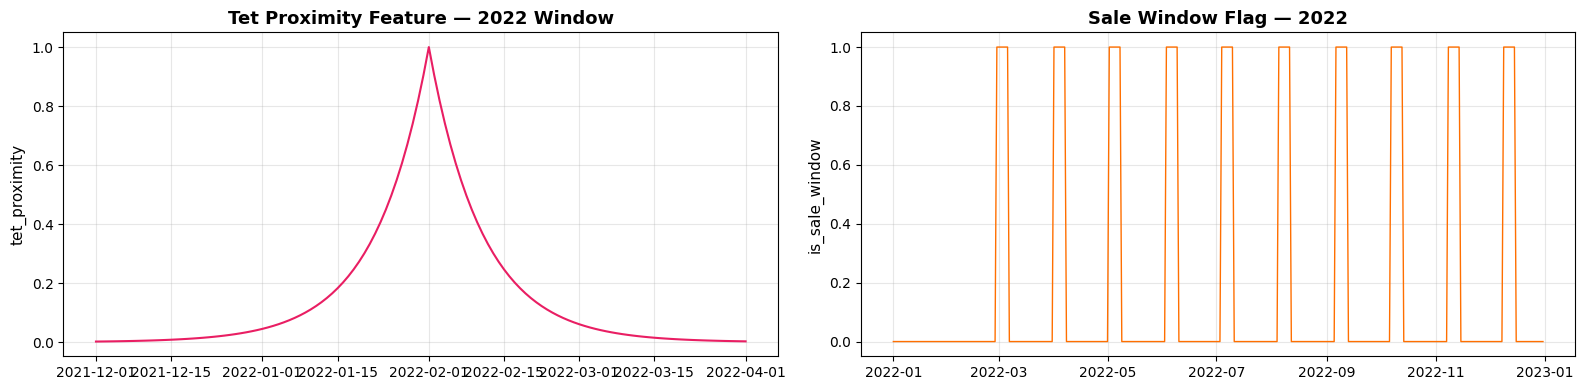

In [50]:
# Visualise Tet proximity
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# 2022 Tet window
mask_2022 = (df_cal.index >= '2021-12-01') & (df_cal.index <= '2022-04-01')
sub = df_cal[mask_2022]
axes[0].plot(sub.index, sub.tet_proximity, color='#E91E63', lw=1.5)
axes[0].set_title('Tet Proximity Feature — 2022 Window')
axes[0].set_ylabel('tet_proximity')

# Mega sale days in 2022
mask_yr = df_cal.year == 2022
axes[1].plot(df_cal[mask_yr].index, df_cal[mask_yr].is_sale_window, color='#FF6F00', lw=1)
axes[1].set_title('Sale Window Flag — 2022')
axes[1].set_ylabel('is_sale_window')

plt.tight_layout()
plt.show()

## 4. Build Prophet Holiday DataFrame

In [51]:
def build_prophet_holidays() -> pd.DataFrame:
    """Build Prophet-compatible holiday DataFrame with lower/upper windows."""
    rows = []

    # ── Tet (Lunar New Year) ──────────────────────────────────────────────
    for tet_dt in TET_DATES:
        rows.append(dict(
            holiday='tet',
            ds=tet_dt,
            lower_window=-21,  # 3 weeks pre-Tet effect
            upper_window=7,    # 1 week post-Tet effect
        ))

    # ── VN National Holidays ──────────────────────────────────────────────
    for yr in range(2012, 2025):
        for (m, d) in VN_HOLIDAYS:
            try:
                rows.append(dict(
                    holiday='vn_holiday',
                    ds=pd.Timestamp(yr, m, d),
                    lower_window=-1,
                    upper_window=1,
                ))
            except Exception:
                pass

    # ── Mega Sale Events ──────────────────────────────────────────────────
    for yr in range(2012, 2025):
        for (m, d) in MEGA_SALE_DAYS:
            try:
                rows.append(dict(
                    holiday='mega_sale',
                    ds=pd.Timestamp(yr, m, d),
                    lower_window=-3,
                    upper_window=3,
                ))
            except Exception:
                pass

    df_holidays = pd.DataFrame(rows)
    df_holidays['ds'] = pd.to_datetime(df_holidays['ds'])
    df_holidays = df_holidays.drop_duplicates(subset=['holiday', 'ds'])
    return df_holidays


df_holidays = build_prophet_holidays()
print(f'Prophet holidays: {len(df_holidays)} rows')
print(df_holidays.groupby('holiday').size())
df_holidays.head(5)

Prophet holidays: 195 rows
holiday
mega_sale     130
tet            13
vn_holiday     52
dtype: int64


,holiday,ds,lower_window,upper_window
0,tet,2012-01-23,-21,7
1,tet,2013-02-10,-21,7
2,tet,2014-01-31,-21,7
3,tet,2015-02-19,-21,7
4,tet,2016-02-08,-21,7


## 5. Auxiliary Feature Engineering (Zero Leakage)

In [52]:
# ── 5a. Web Traffic Profile → median by (month, DOW) ────────────────────
df_web['month'] = df_web.date.dt.month
df_web['dow']   = df_web.date.dt.dayofweek

web_profile = (
    df_web.groupby(['month', 'dow'])[['sessions', 'unique_visitors', 'page_views']]
    .median()
    .reset_index()
)
web_profile.columns = ['month', 'dow', 'med_sessions', 'med_visitors', 'med_pageviews']
print(f'Web profile shape: {web_profile.shape}')
web_profile.head(5)

Web profile shape: (84, 5)


,month,dow,med_sessions,med_visitors,med_pageviews
0,1,0,13279.0,10077.0,58511.0
1,1,1,12998.5,9792.5,55991.0
2,1,2,13271.0,10034.0,55185.0
3,1,3,12850.0,9931.0,53575.0
4,1,4,13150.0,9777.0,55846.0


In [53]:
# ── 5b. Orders Profile → median order count by (month, DOW) ──────────────
df_orders['month'] = df_orders.order_date.dt.month
df_orders['dow']   = df_orders.order_date.dt.dayofweek

order_daily = df_orders.groupby(['order_date', 'month', 'dow']).size().reset_index(name='order_count')
order_profile = (
    order_daily.groupby(['month', 'dow'])['order_count']
    .median()
    .reset_index()
)
order_profile.columns = ['month', 'dow', 'med_order_count']
print(f'Order profile shape: {order_profile.shape}')
order_profile.head(5)

Order profile shape: (84, 3)


,month,dow,med_order_count
0,1,0,104.0
1,1,1,95.0
2,1,2,76.0
3,1,3,77.0
4,1,4,79.0


In [54]:
# ── 5c. Returns Profile → count by month ────────────────────────────────
df_returns['month'] = df_returns.return_date.dt.month
df_returns['year']  = df_returns.return_date.dt.year

returns_monthly = df_returns.groupby(['year', 'month']).size().reset_index(name='return_count')
return_profile = (
    returns_monthly.groupby('month')['return_count']
    .median()
    .reset_index()
)
return_profile.columns = ['month', 'med_return_count']
print(f'Return profile shape: {return_profile.shape}')
return_profile

Return profile shape: (12, 2)


,month,med_return_count
0,1,353.5
1,2,193.0
2,3,285.0
3,4,487.0
4,5,505.0
5,6,561.5
6,7,463.0
7,8,433.0
8,9,356.0
9,10,302.0


In [55]:
# ── 5d. Promotions Profile → count + avg discount by month ───────────────
# Expand promotions to daily active periods
promo_rows = []
for _, row in df_promos.iterrows():
    if pd.isna(row.end_date):
        continue
    for dt in pd.date_range(row.start_date, row.end_date, freq='D'):
        promo_rows.append({'date': dt, 'discount_value': row.discount_value})

df_promo_daily = pd.DataFrame(promo_rows)
df_promo_daily['month'] = df_promo_daily.date.dt.month
df_promo_daily['year']  = df_promo_daily.date.dt.year

# Monthly stats per year, then median across years
promo_monthly = (
    df_promo_daily.groupby(['year', 'month'])
    .agg(promo_count=('discount_value', 'count'),
         avg_discount=('discount_value', 'mean'))
    .reset_index()
)
promo_profile = (
    promo_monthly.groupby('month')
    .agg(med_promo_count=('promo_count', 'median'),
         med_avg_discount=('avg_discount', 'median'))
    .reset_index()
)
print(f'Promo profile shape: {promo_profile.shape}')
promo_profile

Promo profile shape: (11, 3)


,month,med_promo_count,med_avg_discount
0,1,2.0,18.750000
1,2,28.0,15.000000
2,3,14.5,12.100000
3,4,17.0,12.000000
4,6,8.0,18.000000
5,7,23.0,19.333333
6,8,17.5,28.787879
7,9,31.0,11.250000
8,10,1.0,10.000000
9,11,13.0,20.000000


## 6. Historical Median Features for LightGBM

In [56]:
def compute_historical_medians(df_sales: pd.DataFrame) -> dict:
    """
    Compute historical median features using ONLY training data.
    These are static lookups — no future leakage.
    Returns dict of DataFrames.
    """
    df = df_sales.copy()
    df['doy'] = df.Date.dt.dayofyear
    df['dow'] = df.Date.dt.dayofweek
    df['month'] = df.Date.dt.month

    results = {}

    for col in ['Revenue', 'COGS']:
        # Median by DOY
        hist_doy = (
            df.groupby('doy')[col].median()
            .rename(f'hist_doy_{col.lower()}')
        )
        # Median by DOW
        hist_dow = (
            df.groupby('dow')[col].median()
            .rename(f'hist_dow_{col.lower()}')
        )
        # Median by Month
        hist_month = (
            df.groupby('month')[col].median()
            .rename(f'hist_month_{col.lower()}')
        )
        results[f'doy_{col.lower()}']   = hist_doy
        results[f'dow_{col.lower()}']   = hist_dow
        results[f'month_{col.lower()}'] = hist_month

    return results


hist_medians = compute_historical_medians(df_sales)
print('Historical median lookups computed:')
for k, v in hist_medians.items():
    print(f'  {k}: {len(v)} entries')

Historical median lookups computed:
  doy_revenue: 366 entries
  dow_revenue: 7 entries
  month_revenue: 12 entries
  doy_cogs: 366 entries
  dow_cogs: 7 entries
  month_cogs: 12 entries


## 7. Empirical Tet Multipliers (v4 strategy)

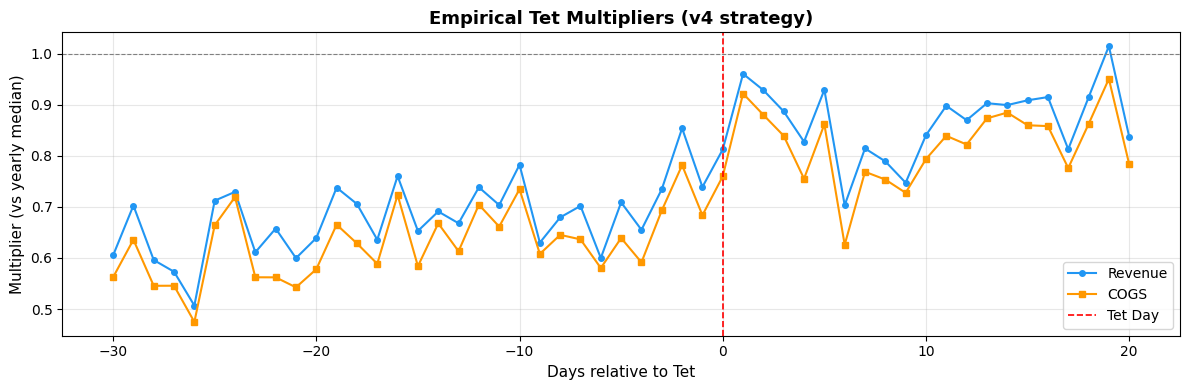

In [57]:
def compute_tet_multipliers(df_sales: pd.DataFrame, col: str) -> pd.Series:
    """
    For each delta in [-30, +20] days around Tet:
      multiplier[delta] = median(sales[tet+delta] / yearly_median)
    """
    df = df_sales.set_index('Date')[[col]].copy()

    # Use Tet dates that are within the training data
    train_tets = [t for t in TET_DATES if df.index.min() <= t <= df.index.max()]

    multipliers = {}
    for delta in range(-30, 21):
        vals = []
        for tet_dt in train_tets:
            target_date = tet_dt + pd.Timedelta(days=delta)
            if target_date not in df.index:
                continue
            yr = target_date.year
            # yearly median for that year
            yr_data = df[df.index.year == yr][col]
            if len(yr_data) < 30:
                continue
            yr_median = yr_data.median()
            if yr_median > 0:
                vals.append(df.loc[target_date, col] / yr_median)
        multipliers[delta] = np.median(vals) if vals else 1.0

    return pd.Series(multipliers, name=f'tet_mult_{col.lower()}')


tet_mult_rev  = compute_tet_multipliers(df_sales, 'Revenue')
tet_mult_cogs = compute_tet_multipliers(df_sales, 'COGS')

# Plot Tet multiplier profile
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tet_mult_rev.index, tet_mult_rev.values, marker='o', ms=4, label='Revenue', color='#2196F3')
ax.plot(tet_mult_cogs.index, tet_mult_cogs.values, marker='s', ms=4, label='COGS', color='#FF9800')
ax.axhline(1.0, color='grey', ls='--', lw=0.8)
ax.axvline(0, color='red', ls='--', lw=1.2, label='Tet Day')
ax.set_xlabel('Days relative to Tet')
ax.set_ylabel('Multiplier (vs yearly median)')
ax.set_title('Empirical Tet Multipliers (v4 strategy)')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Sample Submission Analysis (Scale Anchor)

Sample submission shape: (548, 3)
Date range: 2023-01-01 → 2024-07-01

Revenue stats:
count    5.480000e+02
mean     3.249795e+06
std      1.581698e+06
min      9.773328e+05
25%      2.032802e+06
50%      2.968953e+06
75%      4.182023e+06
max      9.283417e+06
Name: Revenue, dtype: float64

COGS stats:
count    5.480000e+02
mean     2.783810e+06
std      1.360346e+06
min      7.902589e+05
25%      1.706747e+06
50%      2.575698e+06
75%      3.515931e+06
max      8.341542e+06
Name: COGS, dtype: float64

2022 actual Revenue mean : 3,204,791
Sample sub Revenue mean  : 3,249,795
Scale ratio (sub/actual) : 1.0140


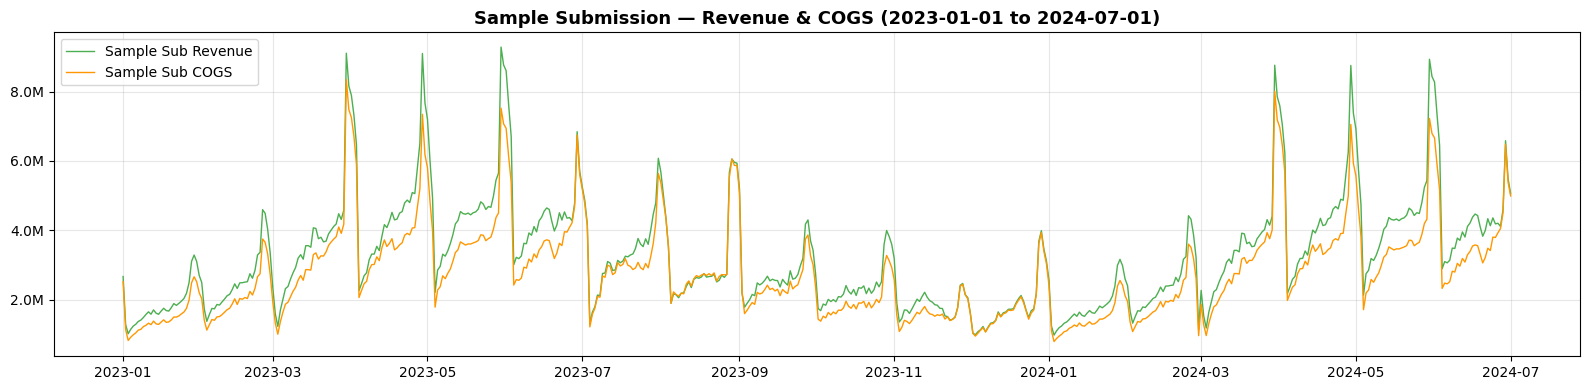

In [58]:
# Analyse sample_submission for scale information (v11 strategy)
print('Sample submission shape:', df_sample.shape)
print(f'Date range: {df_sample.Date.min().date()} → {df_sample.Date.max().date()}')
print(f'\nRevenue stats:')
print(df_sample.Revenue.describe())
print(f'\nCOGS stats:')
print(df_sample.COGS.describe())

# Compare with 2022 actuals
recent_actual = df_sales[df_sales.year == 2022]
print(f'\n2022 actual Revenue mean : {recent_actual.Revenue.mean():,.0f}')
print(f'Sample sub Revenue mean  : {df_sample.Revenue.mean():,.0f}')
print(f'Scale ratio (sub/actual) : {df_sample.Revenue.mean() / recent_actual.Revenue.mean():.4f}')

# Plot sample submission
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_sample.Date, df_sample.Revenue, label='Sample Sub Revenue', color='#4CAF50', lw=1)
ax.plot(df_sample.Date, df_sample.COGS, label='Sample Sub COGS', color='#FF9800', lw=1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_title('Sample Submission — Revenue & COGS (2023-01-01 to 2024-07-01)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Save All Processed Data

In [59]:
# Sales clean
df_sales_clean = df_sales.copy()
df_sales_clean.to_csv(CLEAN_DIR / 'sales_clean.csv', index=False)

# Calendar features
df_cal.to_csv(CLEAN_DIR / 'calendar_features.csv')

# Prophet holidays
df_holidays.to_csv(CLEAN_DIR / 'prophet_holidays.csv', index=False)

# Aux profiles
web_profile.to_csv(CLEAN_DIR / 'aux_web_profile.csv', index=False)
order_profile.to_csv(CLEAN_DIR / 'aux_orders_profile.csv', index=False)
return_profile.to_csv(CLEAN_DIR / 'aux_returns_profile.csv', index=False)
promo_profile.to_csv(CLEAN_DIR / 'aux_promos_profile.csv', index=False)

# Tet multipliers
tet_mults = pd.DataFrame({
    'delta': tet_mult_rev.index,
    'revenue_mult': tet_mult_rev.values,
    'cogs_mult': tet_mult_cogs.values,
})
tet_mults.to_csv(CLEAN_DIR / 'tet_multipliers.csv', index=False)

# Historical medians — save as JSON-friendly CSV
for key, series in hist_medians.items():
    series.to_csv(CLEAN_DIR / f'hist_median_{key}.csv', header=True)

print('✅ All files saved to:', CLEAN_DIR)
for f in sorted(CLEAN_DIR.glob('*.csv')):
    print(f'  {f.name}: {f.stat().st_size:,} bytes')

✅ All files saved to: /content/drive/My Drive/Datathon_VinTelligence/data/data_clean
  Dataset_1_Revenue_Core.csv: 603,552 bytes
  Dataset_2_Customer_Insights.csv: 14,143,693 bytes
  Dataset_3_Operations_Logistics.csv: 33,883,776 bytes
  Dataset_4_Marketing_Traffic.csv: 405,232 bytes
  aux_orders_profile.csv: 876 bytes
  aux_promos_profile.csv: 200 bytes
  aux_returns_profile.csv: 122 bytes
  aux_web_profile.csv: 2,463 bytes
  calendar_features.csv: 2,174,426 bytes
  hist_median_dow_cogs.csv: 120 bytes
  hist_median_dow_revenue.csv: 130 bytes
  hist_median_doy_cogs.csv: 5,743 bytes
  hist_median_doy_revenue.csv: 5,766 bytes
  hist_median_month_cogs.csv: 205 bytes
  hist_median_month_revenue.csv: 193 bytes
  mcq_answers.csv: 1,327 bytes
  prophet_holidays.csv: 5,094 bytes
  sales_clean.csv: 221,500 bytes
  tet_multipliers.csv: 2,117 bytes
  v3_cv_results.csv: 540 bytes


In [60]:
print('='*60)
print('NOTEBOOK 1 COMPLETE — Data Preparation')
print('='*60)
print(f'Training period : {df_sales.Date.min().date()} → 2022-12-31')
print(f'Forecast period : 2023-01-01 → 2024-07-01 (548 days)')
print(f'Calendar feats  : {df_cal.shape[1]} columns')
print(f'Prophet holidays: {len(df_holidays)} events')
print(f'Tet multipliers : {len(tet_mults)} delta values')
print('\n→ Next: Run 02_baseline_models.ipynb')

NOTEBOOK 1 COMPLETE — Data Preparation
Training period : 2012-07-04 → 2022-12-31
Forecast period : 2023-01-01 → 2024-07-01 (548 days)
Calendar feats  : 46 columns
Prophet holidays: 195 events
Tet multipliers : 51 delta values

→ Next: Run 02_baseline_models.ipynb
